In [ ]:
# !pip3 install roboflow ultralytics
# paste here your code snippet from roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="################")
project = rf.workspace("bee-analysis").project("bees-l91gs")
version = project.version(2)
dataset = version.download("yolo26")
                

### Train model locally

In [ ]:
from ultralytics import YOLO

def main():
    model = YOLO(model="yolo26n.pt")
    # model.train(data="path to your data.yaml file", epochs=25, imgsz=640, verbose=True, batch=8)
    model.train(data="./bees-2/data.yaml", epochs=25, imgsz=640, verbose=True, batch=8)
    model.val()
    model.export()
if __name__ == '__main__':
    main()

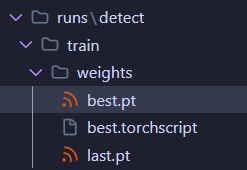

### Load model

In [ ]:
import os
from os import path
print(os.getcwd())

In [ ]:
# Load your trained model
model = YOLO("path to your best.pt file")

### Prediction
Default ultralytics visualization.<br>
The output can look different depending if your model originates from roboflow or is trained locally.

In [ ]:
# Make a prediction

path = "path to your test image"
result = model.predict(path)
result = result[0] if isinstance(result, list) else result
result.save("prediction_default.jpg")

from IPython.display import Image
Image("prediction_default.jpg")

### Count the instances from a class

In [ ]:
# !pip3 install supervision
import supervision as sv

print(model.names)
def get_keys_from_value(d, val):
    return [k for k, v in d.items() if v == val]

detections = sv.Detections.from_ultralytics(result)
detections = detections[detections.class_id == get_keys_from_value(model.names, 'Drone')] # if necessary replace by your own class
print("Amount of drones: ",len(detections))

### Create a simple interface with gradio
https://www.gradio.app/

In [ ]:
# !pip install gradio
import PIL.Image as Image
import gradio as gr

from ultralytics import ASSETS

def predict_image(img, conf_threshold, iou_threshold):
    results = model.predict(
        source=img,
        conf=conf_threshold,
        iou=iou_threshold,
        show_labels=True,
        show_conf=True,
        imgsz=640,
        agnostic_nms=True
    )

    for r in results:
        im_array = r.plot()
        im = Image.fromarray(im_array[..., ::-1])

    result = model.predict(img)
    result = result[0] if isinstance(result, list) else result 
    detections = sv.Detections.from_ultralytics(result)
    detections = detections[detections.class_id == get_keys_from_value(model.names, 'Drone')]

    print(results)
    return im, {len(detections)}


iface = gr.Interface(
    fn=predict_image,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Slider(minimum=0, maximum=1, value=0.25, label="Confidence threshold"),
        gr.Slider(minimum=0, maximum=1, value=0.45, label="IoU threshold")
    ],
    outputs=[gr.Image(type="pil", label="Result"), gr.Textbox(label="Amount of drones")],
    title="Ultralytics Gradio",
    description="Upload images for inference. The Ultralytics YOLOv8n model is used by default.",
    theme = gr.themes.Monochrome()

)

if __name__ == '__main__':
    iface.launch()